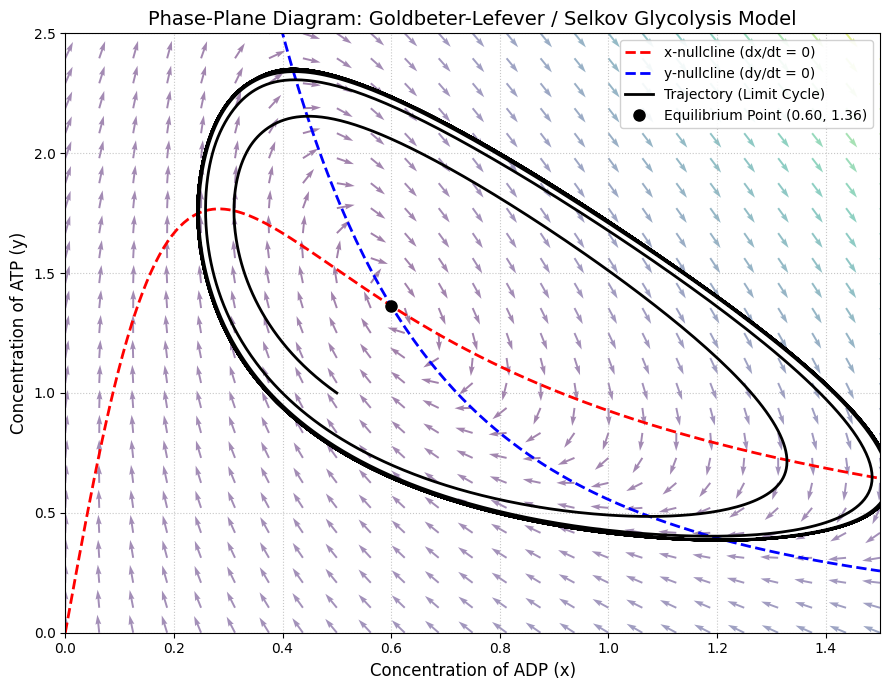

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the standard Goldbeter-Lefever / Selkov glycolysis model ODEs
def glycolysis_model(t, state, a, b):
    x, y = state
    # x represents the concentration of ADP
    # y represents the concentration of ATP
    dxdt = -x + a*y + (x**2)*y
    dydt = b - a*y - (x**2)*y
    return [dxdt, dydt]

# Parameters chosen to ensure an unstable equilibrium and a stable limit cycle
a = 0.08
b = 0.6

# 1. Create a grid for the vector field (quiver plot)
x_range = np.linspace(0, 1.5, 25)
y_range = np.linspace(0, 2.5, 25)
X, Y = np.meshgrid(x_range, y_range)

# Calculate the derivatives at each point on the grid
U = -X + a*Y + (X**2)*Y
V = b - a*Y - (X**2)*Y

# Normalize the vectors so the arrows are of equal length (for cleaner visualization)
norm = np.hypot(U, V)
# Avoid division by zero
norm[norm == 0] = 1
U_norm = U / norm
V_norm = V / norm

# 2. Calculate Nullclines
x_null = np.linspace(0, 1.5, 200)
# y-nullcline: set dy/dt = 0 and solve for y
y_nullcline = b / (a + x_null**2)
# x-nullcline: set dx/dt = 0 and solve for y
x_nullcline = x_null / (a + x_null**2)

# 3. Solve the ODE to show a sample trajectory (Limit Cycle)
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 5000)
# Start slightly off the equilibrium to watch it spiral into the limit cycle
initial_state = [0.5, 1.0]
sol = solve_ivp(glycolysis_model, t_span, initial_state, args=(a, b), t_eval=t_eval)

# --- Plotting ---
plt.figure(figsize=(9, 7))

# Plot the normalized vector field
plt.quiver(X, Y, U_norm, V_norm, norm, cmap='viridis', alpha=0.5)

# Plot the nullclines
plt.plot(x_null, x_nullcline, 'r--', linewidth=2, label='x-nullcline (dx/dt = 0)')
plt.plot(x_null, y_nullcline, 'b--', linewidth=2, label='y-nullcline (dy/dt = 0)')

# Plot the simulated trajectory
plt.plot(sol.y[0], sol.y[1], 'k-', linewidth=2, label='Trajectory (Limit Cycle)')

# Plot the equilibrium (fixed) point where the nullclines intersect
x_eq = b
y_eq = b / (a + b**2)
plt.plot(x_eq, y_eq, 'ko', markersize=8, label=f'Equilibrium Point ({x_eq:.2f}, {y_eq:.2f})')

# Formatting the graph
plt.title('Phase-Plane Diagram: Goldbeter-Lefever / Selkov Glycolysis Model', fontsize=14)
plt.xlabel('Concentration of ADP (x)', fontsize=12)
plt.ylabel('Concentration of ATP (y)', fontsize=12)
plt.xlim(0, 1.5)
plt.ylim(0, 2.5)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()